In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Контрольная работа:
# 1. Заполните пропущенные значения в столбце Age медианным возрастом.
# 2. Столбец Embarked pаполните их самым часто встречающимся значением (модой).
# 3. Удалите столбец Cabin.
# 4. Сгруппируйте данные по полу (Sex) и посчитайте средний процент выживших (Survived) для мужчин и женщин.
# 5. Сгруппируйте данные по классу каюты (Pclass). Для каждого класса посчитайте:
#   - Медианный возраст (Age)
#   - Среднюю стоимость билета (Fare)
#   - Общее количество выживших (Survived)
# 6. Создайте сводную таблицу, которая показывает средний процент выживаемости (Survived) в зависимости от класса каюты (Pclass) и пола (Sex).
# 7. В столбце имя (Name) содержатся титулы пассажиров ("Mr.", "Mrs.", "Miss.", и др.). Создайте новый столбец Title, извлекая эти титулы. 
#   - (Можно использовать регулярного выражения для этого: r'([A-Za-z]+)\.')
# 8. Постройте гистограмму распределения стоимости билетов (Fare).
# 9. Постройте столбчатую диаграмму среднего процента выживших (Survived) по полу ('Sex').
# 10. Создайте датафрейм (например можно через csv или excel):
#   +-----------+--------------+
#   + Embarked  +  Port_Name   +
#   +-----------+--------------+
#   + S         +  Southampton +
#   + C         +  Cherbourg   +
#   + Q         +  Queenstown  +
#   +-----------+--------------+
#   - Объедините (merge) ваш основной DataFrame с этой новой таблицей по столбцу Embarked. Убедитесь, что в итоговой таблице появился столбец Port_Name.

In [3]:
# 0. Загрузить дататсет Titanic с Kaggle или с другого источника.
df = pd.read_csv('../data/raw/Titanic-Dataset.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# 1. Заполните пропущенные значения в столбце Age медианным возрастом.
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

In [7]:
# 2. Столбец Embarked pаполните их самым часто встречающимся значением (модой).
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

In [8]:
# 3. Удалите столбец Cabin.
df = df.drop('Cabin', axis=1)

In [9]:
# 4. Сгруппируйте данные по полу (Sex) и посчитайте средний процент выживших (Survived) для мужчин и женщин.
survival_by_sex = df.groupby('Sex')['Survived'].mean()
survival_by_sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [10]:
# 5. Сгруппируйте данные по классу каюты (Pclass). Для каждого класса посчитайте:
#   - Медианный возраст (Age)
#   - Среднюю стоимость билета (Fare)
#   - Общее количество выживших (Survived)
stats_by_class = df.groupby('Pclass').agg(
    Mean_Age=('Age', 'median'),
    Mean_Fare=('Fare', 'mean'),
    Total_Survived=('Survived', 'sum')
)
stats_by_class

,Mean_Age,Mean_Fare,Total_Survived
Pclass,,,
1,35.0,84.154687,136
2,28.0,20.662183,87
3,28.0,13.675550,119


In [11]:
# 6. Создайте сводную таблицу, которая показывает средний процент выживаемости (Survived) в зависимости от класса каюты (Pclass) и пола (Sex).
pivot_survival = df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')
pivot_survival

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [12]:
# 7. В столбце имя (Name) содержатся титулы пассажиров ("Mr.", "Mrs.", "Miss.", и др.). Создайте новый столбец Title, извлекая эти титулы. 
#   - (Можно использовать регулярного выражения для этого: r'([A-Za-z]+)\.')
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.')
title_counts = df['Title'].value_counts()
title_counts

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

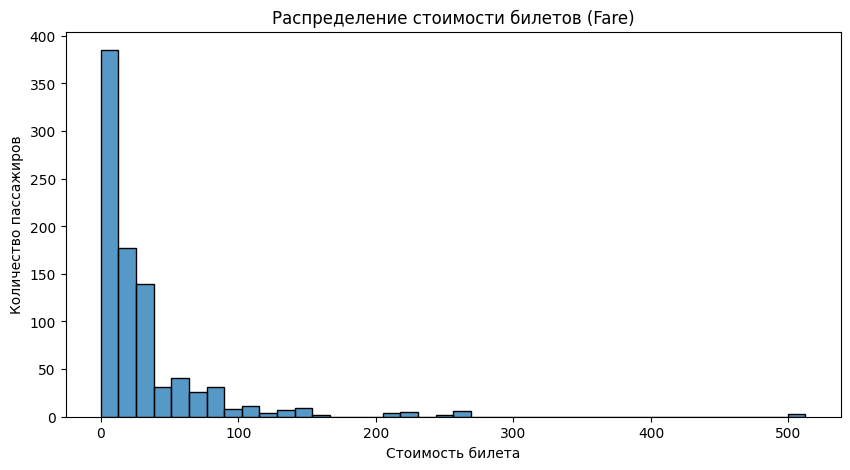

In [13]:
# 8. Постройте гистограмму распределения стоимости билетов (Fare).
plt.figure(figsize=(10, 5))
plt.title('Распределение стоимости билетов (Fare)')
plt.xlabel('Стоимость билета')
plt.ylabel('Количество пассажиров')
sns.histplot(data=df, x='Fare', bins=40) # kde=True добавляет линию плотности
plt.show()

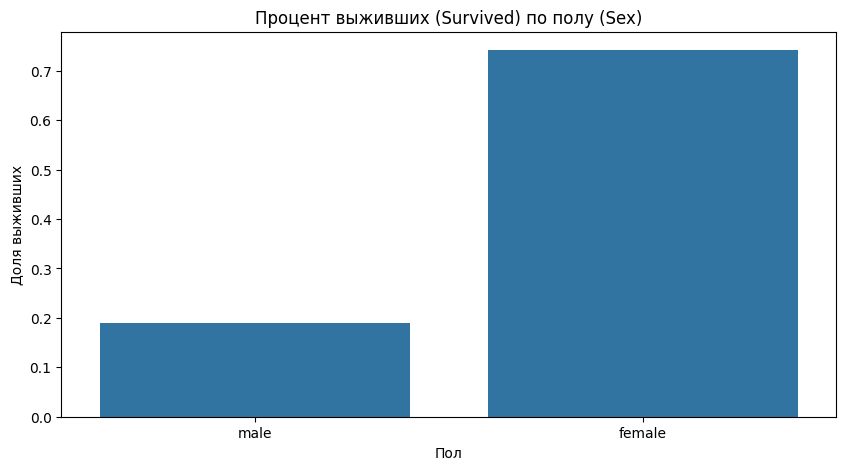

In [14]:
# 9. Постройте столбчатую диаграмму среднего процента выживших (Survived) по полу ('Sex').
plt.figure(figsize=(10, 5))
plt.title('Процент выживших (Survived) по полу (Sex)')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
sns.barplot(data=df, x='Sex', y='Survived', estimator='mean', errorbar=None)
plt.show()

In [15]:
# 10. Создайте датафрейм:
#   +-----------+--------------+
#   + Embarked  +  Port_Name   +
#   +-----------+--------------+
#   + S         +  Southampton +
#   + C         +  Cherbourg   +
#   + Q         +  Queenstown  +
#   +-----------+--------------+
#   - Объедините (merge) ваш основной DataFrame с этой новой таблицей по столбцу Embarked. Убедитесь, что в итоговой таблице появился столбец Port_Name.
ports = pd.DataFrame({
    'Embarked': ['S', 'C', 'Q'],
    'Port_Name': ['Southampton', 'Cherbourg', 'Queenstown']
})
df_merged = pd.merge(df, ports, on='Embarked', how='left')
df_merged

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Port_Name
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,Southampton
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Rev,Southampton
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss,Southampton
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,Miss,Southampton
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Mr,Cherbourg
